# 1. Import and Hardware Setup

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset

import os
import math
import random
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

!pip install tqdm -q
from tqdm.auto import tqdm

^C
ERROR: Operation cancelled by user


In [37]:
DATA_PATH = './data'

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

cuda


# 2. Hyperparamter

In [38]:
BATCH_SIZE = 128
IMG_SIZE = 128
IN_CHANNELS = 3
PATCH_SIZE = 8  # Each patch is 16x16 pixels

LR = 1.5e-4
EPOCHS = 100
SEED = 42
NUM_CLASSES = 50

# ----- MAE Masking -----
MASK_RATIO = 0.60  # 75% of patches are masked

# ----- ConvNeXt Encoder -----
ENC_EMBED_DIM = 768
ENC_DEPTH = 8

# ----- ConvNeXt Decoder -----
DEC_EMBED_DIM = 512
DEC_DEPTH = 4

# ----- Common -----
DROP_RATE = 0.0  # No dropout during MAE pre-training

NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
print(f"Number of patches: {NUM_PATCHES}")
print(f"Visible patches: {int(NUM_PATCHES * (1 - MASK_RATIO))}")
print(f"Masked patches: {int(NUM_PATCHES * MASK_RATIO)}")

Number of patches: 64
Visible patches: 16
Masked patches: 48


# 3. Data Preparation

In [39]:
def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [40]:
# MAE pre-training uses minimal augmentation.
# The masking itself acts as a strong regularizer.
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

# Apply seed
set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

filtered_indices = [i for i, label in enumerate(dummy_data._labels) if label < NUM_CLASSES]

train_size = int(0.8 * len(filtered_indices))
val_size = len(filtered_indices) - train_size
split_generator = torch.Generator().manual_seed(SEED)

filtered_dummy_data = Subset(dummy_data, filtered_indices)
train_tmp_subset, val_tmp_subset = random_split(
    filtered_dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = [filtered_indices[i] for i in train_tmp_subset.indices]
val_indices = [filtered_indices[i] for i in val_tmp_subset.indices]

train_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=train_transform,
)

val_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=val_transform,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)


dummy_test_dataset = datasets.Food101(root=DATA_PATH, split="test", download=True)
test_filterd_indices = [
    i for i, label in enumerate(dummy_test_dataset._labels) if label < NUM_CLASSES
]

test_dataset_full = datasets.Food101(
    root=DATA_PATH,
    split="test",
    download=False,
    transform=val_transform,
)
test_dataset = Subset(test_dataset_full, test_filterd_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)


# 4. Model Architecture

In [41]:
# ============================================================
# ConvNeXt V2 Building Blocks (with GRN)
# ============================================================
import torch
import torch.nn as nn

class GRN(nn.Module):
    """ GRN (Global Response Normalization) layer """
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        # x is expected to be in (N, H, W, C) format
        Gx = torch.norm(x, p=2, dim=(1,2), keepdim=True)
        Nx = Gx / (Gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * Nx) + self.beta + x

class ConvNeXtBlock(nn.Module):
    """ConvNeXt V2 Block for MAE (includes GRN)"""
    def __init__(self, dim, drop_rate=0.0, kernel_size=5):
        super().__init__()
        padding = kernel_size // 2
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=padding, groups=dim) # depthwise
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim) # pointwise/1x1 convs, implemented with linear layers
        self.act = nn.GELU()
        self.grn = GRN(4 * dim)
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.drop = nn.Dropout(drop_rate) if drop_rate > 0.0 else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1) # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)
        x = self.drop(x)
        x = x.permute(0, 3, 1, 2) # (N, H, W, C) -> (N, C, H, W)
        x = input + x
        return x

# ============================================================
# Patch Embedding
# ============================================================
class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and project to embedding dim."""
    def __init__(self, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)

# ============================================================
# ConvNeXt MAE Encoder
# ============================================================
class ConvNeXt_Encoder(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim, depth, drop_rate):
        super().__init__()
        self.patch_embed = PatchEmbed(patch_size, in_channels, embed_dim)
        
        # Learnable mask token to replace masked patches
        self.mask_token = nn.Parameter(torch.zeros(1, embed_dim, 1, 1))
        
        self.blocks = nn.ModuleList([
            ConvNeXtBlock(dim=embed_dim, drop_rate=drop_rate, kernel_size=5)
            for _ in range(depth)
        ])
        
    def random_masking(self, x, mask_ratio):
        B, C, H, W = x.shape
        N = H * W
        num_keep = int(N * (1 - mask_ratio))
        
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        mask_2d = mask.view(B, 1, H, W)
        return mask, mask_2d
        
    def forward(self, x, mask_ratio):
        x = self.patch_embed(x)
        B, C, H, W = x.shape
        
        mask, mask_2d = self.random_masking(x, mask_ratio)
        
        # Pseudo-Sparse Strategy: Only process visible patches, zero out masked areas
        for block in self.blocks:
            # 1. Zero out masked patches so they don't leak into visible patches
            x = x * (1 - mask_2d)
            # 2. Block forward pass
            x = block(x)
            
        # Final replacement: inject the learnable mask token for the decoder
        mask_token_expanded = self.mask_token.expand(B, -1, H, W)
        x = x * (1 - mask_2d) + mask_token_expanded * mask_2d
            
        return x, mask

    def forward_features(self, x):
        x = self.patch_embed(x)
        for block in self.blocks:
            x = block(x)
        # Reshape from (B, D, H, W) to (B, N, D) to match ViT output expected by t-SNE
        B, D, H, W = x.shape
        x = x.view(B, D, H * W).transpose(1, 2)
        return x

# ============================================================
# ConvNeXt MAE Decoder
# ============================================================
class ConvNeXt_Decoder(nn.Module):
    def __init__(self, patch_size, in_channels, enc_embed_dim, dec_embed_dim, depth, drop_rate):
        super().__init__()
        self.decoder_embed = nn.Conv2d(enc_embed_dim, dec_embed_dim, kernel_size=1)
        
        self.blocks = nn.ModuleList([
            ConvNeXtBlock(dim=dec_embed_dim, drop_rate=drop_rate, kernel_size=5)
            for _ in range(depth)
        ])
        
        self.head = nn.Conv2d(dec_embed_dim, patch_size * patch_size * in_channels, kernel_size=1)
        
    def forward(self, x):
        x = self.decoder_embed(x)
        
        for block in self.blocks:
            x = block(x)
            
        pred = self.head(x)
        B, C, H, W = pred.shape
        pred = pred.view(B, C, H * W).transpose(1, 2)
        return pred

# ============================================================
# Full ConvNeXt MAE Model
# ============================================================
class MaskedAutoencoder(nn.Module):
    def __init__(
        self, img_size, patch_size, in_channels,
        enc_embed_dim, enc_depth,
        dec_embed_dim, dec_depth,
        drop_rate=0.0, norm_pix_loss=True,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.norm_pix_loss = norm_pix_loss
        
        self.encoder = ConvNeXt_Encoder(
            img_size, patch_size, in_channels,
            enc_embed_dim, enc_depth, drop_rate
        )
        
        self.decoder = ConvNeXt_Decoder(
            patch_size, in_channels,
            enc_embed_dim, dec_embed_dim, dec_depth, drop_rate
        )

    def patchify(self, imgs):
        P = self.patch_size
        C = self.in_channels
        B, _, H, W = imgs.shape
        h, w = H // P, W // P

        x = imgs.reshape(B, C, h, P, w, P)
        x = x.permute(0, 2, 4, 3, 5, 1)  # (B, h, w, P, P, C)
        x = x.reshape(B, h * w, P * P * C)
        return x

    def unpatchify(self, patches):
        P = self.patch_size
        C = self.in_channels
        B = patches.shape[0]
        h = w = int(patches.shape[1] ** 0.5)

        x = patches.reshape(B, h, w, P, P, C)
        x = x.permute(0, 5, 1, 3, 2, 4)  # (B, C, h, P, w, P)
        x = x.reshape(B, C, h * P, w * P)
        return x

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1e-6).sqrt()

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask = self.encoder(imgs, mask_ratio)
        pred = self.decoder(latent)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


In [42]:
model = MaskedAutoencoder(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    enc_embed_dim=ENC_EMBED_DIM,
    enc_depth=ENC_DEPTH,
    dec_embed_dim=DEC_EMBED_DIM,
    dec_depth=DEC_DEPTH,
    drop_rate=DROP_RATE,
    norm_pix_loss=True,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")

Total parameters: 47.98M
Trainable parameters: 47.98M


# 5. Train Preparation

In [43]:
class EarlyStopping:
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)



In [44]:
# No separate criterion needed — loss is computed inside the MAE model.
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.amp.GradScaler(device=device)

In [45]:
def train(model, loader, optimizer, scaler, mask_ratio=MASK_RATIO):
    """Run one training epoch for MAE."""
    model.train()
    train_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad()

        with torch.autocast(device_type=device.type):
            loss, _, _ = model(images, mask_ratio=mask_ratio)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.detach() * images.size(0)

    return train_loss.item() / len(loader.dataset)


def validate(model, loader, mask_ratio=MASK_RATIO):
    """Run one validation epoch for MAE."""
    model.eval()
    val_loss = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, _ in loop:
            images = images.to(device)

            with torch.autocast(device_type=device.type):
                loss, _, _ = model(images, mask_ratio=mask_ratio)

            val_loss += loss.detach() * images.size(0)

    return val_loss.item() / len(loader.dataset)

# 6. Training

In [46]:
early_stopping = EarlyStopping(patience=5, save_path="best_mae_checkpoint.pth")
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train(model, train_loader, optimizer, scaler)
    val_loss = validate(model, val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best model for evaluation
model.load_state_dict(torch.load("best_mae_checkpoint.pth", weights_only=True, map_location=device))

Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/100: Train Loss: 0.657803 | Val Loss: 0.579307


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 90/100: Train Loss: 0.441669 | Val Loss: 0.438799
Early Stopping counter: 4 out of 5


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 91/100: Train Loss: 0.441372 | Val Loss: 0.438993
Early Stopping counter: 5 out of 5
Early stopping triggered


<All keys matched successfully>

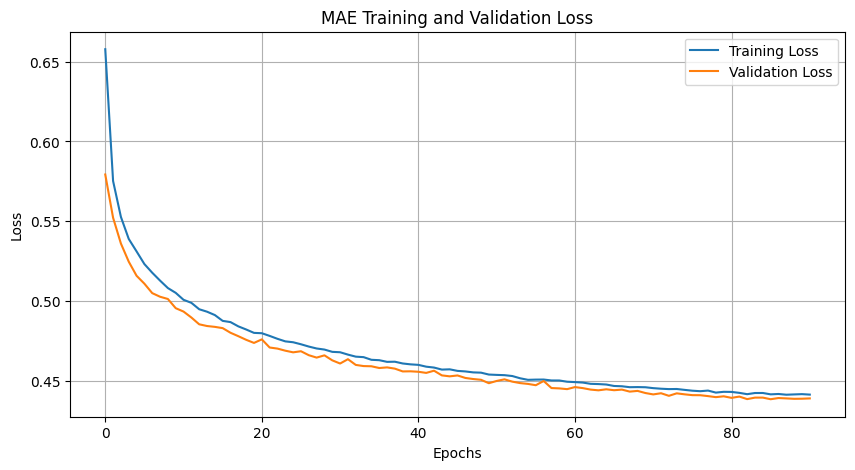

In [47]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('MAE Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 7. Results

Visualizing MAE reconstruction...


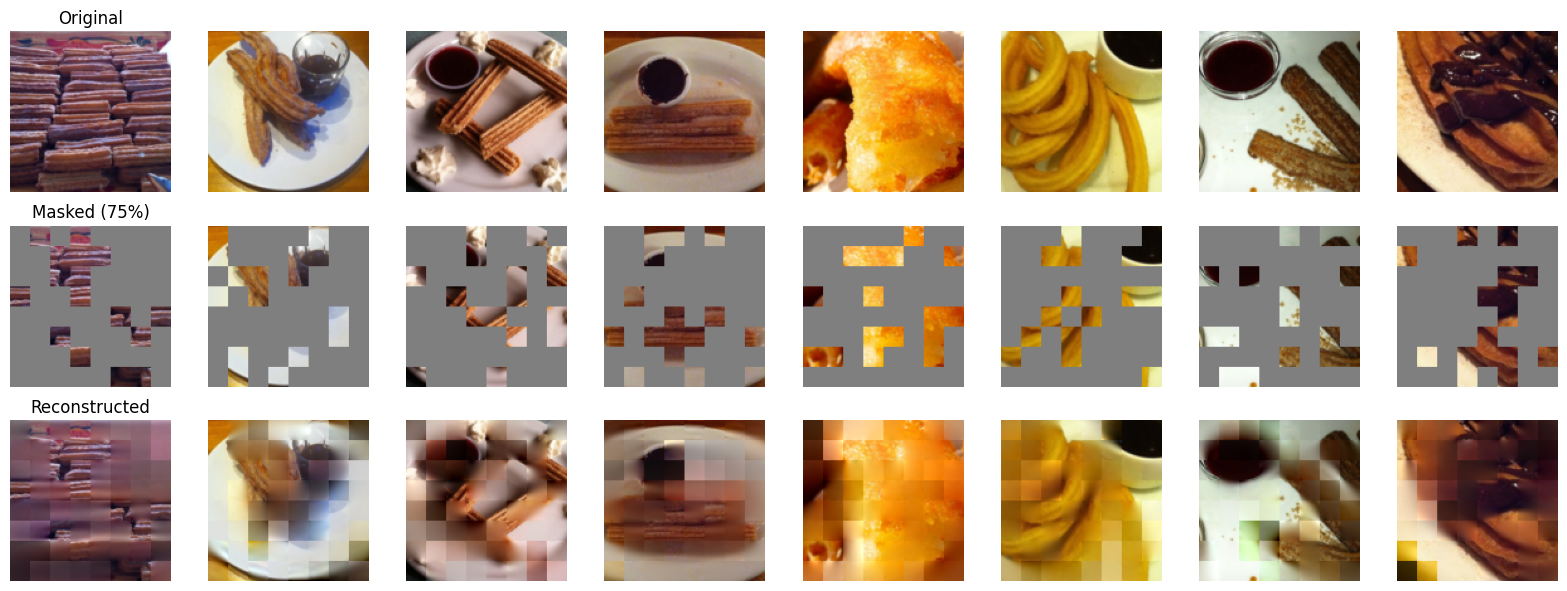

In [48]:
def visualize_mae_reconstruction(model, test_loader, num_images=8, mask_ratio=MASK_RATIO):
    """
    Visualize MAE reconstruction: Original | Masked | Reconstructed.

    Shows which patches were masked and how well the model reconstructs them.
    """
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images[:num_images].to(device)

    with torch.no_grad():
        with torch.autocast(device_type=device.type):
            loss, pred, mask = model(images, mask_ratio=mask_ratio)

    # --- Denormalize predictions if norm_pix_loss was used ---
    # The model predicts normalized patch values (zero mean, unit variance per patch).
    # To visualize correctly, we must reverse this normalization using
    # the original patch statistics.
    pred_float = pred.float()
    if model.norm_pix_loss:
        target_patches = model.patchify(images)  # (B, N, P^2 * C)
        patch_mean = target_patches.mean(dim=-1, keepdim=True)
        patch_var = target_patches.var(dim=-1, keepdim=True)
        # Reverse: pred_denorm = pred * sqrt(var + eps) + mean
        pred_float = pred_float * (patch_var + 1e-6).sqrt() + patch_mean

    # Unpatchify predictions to image space
    pred_imgs = model.unpatchify(pred_float).clamp(0, 1).cpu()
    images_cpu = images.cpu()
    mask_cpu = mask.cpu()  # (B, N)

    P = model.patch_size
    C = model.in_channels
    _, _, H, W = images_cpu.shape
    h, w = H // P, W // P

    # --- Build masked view ---
    # Expand mask to pixel-level: mask_cpu (B, N) -> (B, C, H, W)
    # FIX: Must permute before reshape to correctly form 2D patch blocks
    # instead of horizontal stripes.
    mask_img = mask_cpu.reshape(-1, h, w)              # (B, h, w)
    mask_img = mask_img.unsqueeze(-1).unsqueeze(-1)     # (B, h, w, 1, 1)
    mask_img = mask_img.expand(-1, -1, -1, P, P)        # (B, h, w, P, P)
    mask_img = mask_img.permute(0, 1, 3, 2, 4)          # (B, h, P, w, P)  <-- FIX
    mask_img = mask_img.reshape(-1, h * P, w * P)        # (B, H, W)
    mask_img = mask_img.unsqueeze(1).expand(-1, C, -1, -1)  # (B, C, H, W)

    # Masked view: visible patches from original, masked patches as gray
    masked_view = images_cpu.clone()
    masked_view[mask_img == 1] = 0.5  # Gray for masked patches

    # --- Build composite reconstruction ---
    # Show original pixels for visible patches, predictions for masked patches
    composite = images_cpu.clone()
    composite[mask_img == 1] = pred_imgs[mask_img == 1]

    fig, axes = plt.subplots(3, num_images, figsize=(num_images * 2, 6))
    row_titles = ['Original', f'Masked ({int(mask_ratio*100)}%)', 'Reconstructed']

    for i in range(num_images):
        for row, data in enumerate([images_cpu, masked_view, composite]):
            ax = axes[row, i]
            img = np.transpose(data[i].numpy(), (1, 2, 0))
            ax.imshow(img)
            ax.axis('off')
            if i == 0:
                ax.set_title(row_titles[row])

    plt.tight_layout()
    plt.show()


# Show results
print("Visualizing MAE reconstruction...")
visualize_mae_reconstruction(model, test_loader, num_images=8)


# 8. Latent Space Analysis (t-SNE)

Starting t-SNE with 600 filtered images from 6 classes...


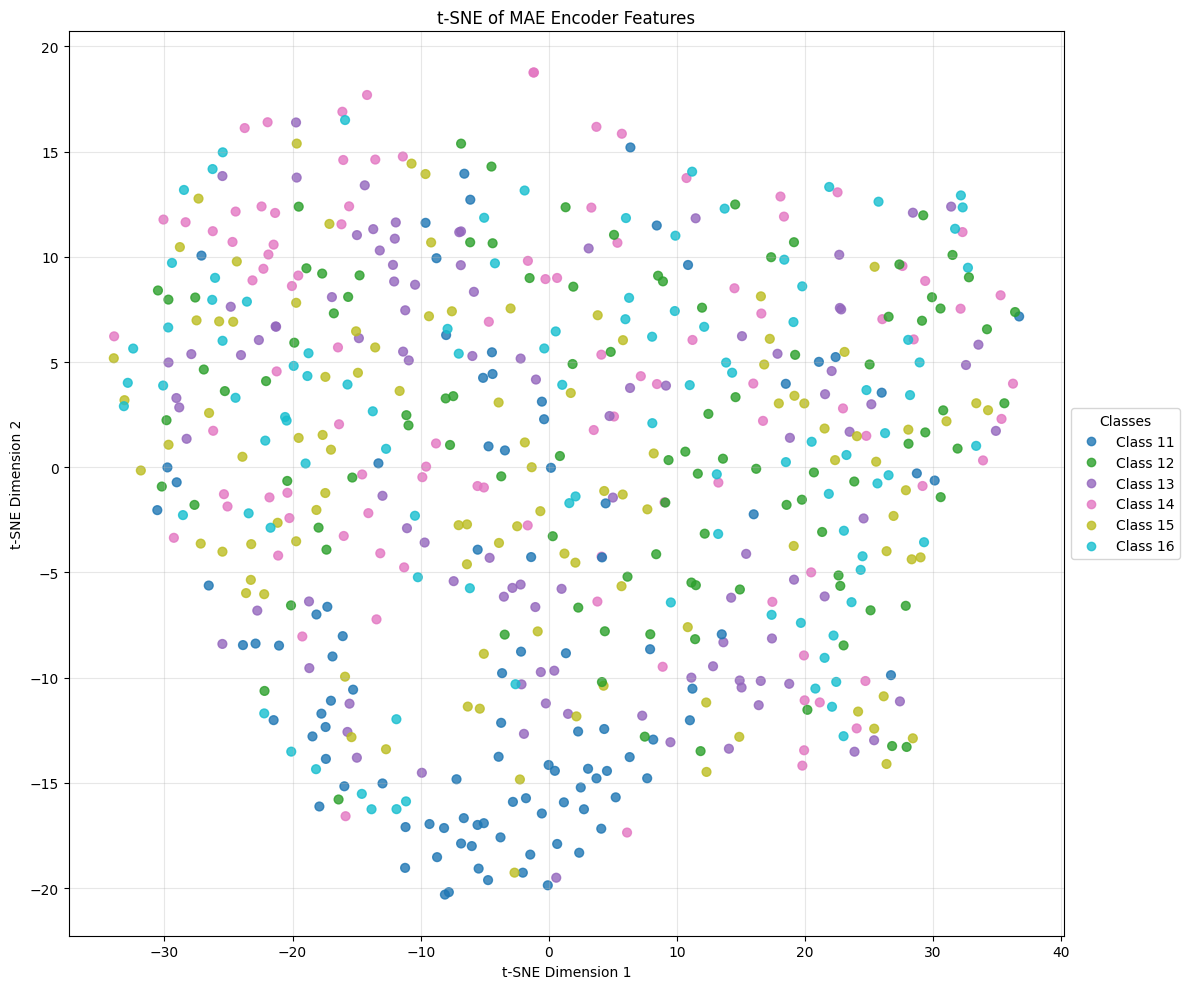

In [49]:
!pip install scikit-learn -q
from sklearn.manifold import TSNE


def visualize_tsne(
    model,
    dataloader,
    num_samples_per_class=100,
    target_classes=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
):
    """Visualize t-SNE of MAE encoder features (using all patches, no masking)."""
    model.eval()
    latents = []
    labels = []

    # Create a list of human-readable class names
    try:
        class_names = [dataloader.dataset.classes[i] for i in target_classes]
    except AttributeError:
        # Fallback
        class_names = [f"Class {i}" for i in target_classes]

    class_counts = {c: 0 for c in target_classes}

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)

            # Use forward_features (no masking) to get patch embeddings
            features = model.encoder.forward_features(images)  # (B, N, D)
            # Global average pooling over patch tokens
            latent = features.mean(dim=1)  # (B, D)

            # Filter the batch
            for i in range(len(targets)):
                target_idx = targets[i].item()
                if (
                    target_idx in target_classes
                    and class_counts[target_idx] < num_samples_per_class
                ):
                    latents.append(latent[i].cpu().numpy())
                    labels.append(target_classes.index(target_idx))
                    class_counts[target_idx] += 1

            if all(count >= num_samples_per_class for count in class_counts.values()):
                break

    latents = np.array(latents)
    labels = np.array(labels)

    print(f"Starting t-SNE with {len(latents)} filtered images from {len(target_classes)} classes...")
    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    latents_2d = tsne.fit_transform(latents)

    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(
        latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap="tab10", alpha=0.8, s=40
    )

    handles, _ = scatter.legend_elements(prop="colors")
    plt.legend(
        handles,
        class_names,
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )

    plt.title("t-SNE of MAE Encoder Features")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


visualize_tsne(model, test_loader, target_classes=[11, 12, 13, 14, 15, 16])
